# **Tutorial 06 - Penalized Least Squares**: Supplementary Interactive Material

-------------------------------------------------------------------------

This tutorial looks at the penalty term itself: what the different $p$ norms actually measure, and what happens when we minimize an $\ell_1$ penalty on the *gradient* of an image rather than on the image itself.

Sparse recovery — solving an underdetermined $Ax = b$ for a sparse $x$ — is taken up in Tutorial 07.


In [ ]:
import numpy as np, matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display
from PIL import Image


## Example 01: Revisiting the P norm from Our first notebook

The following visualization gives us a chance to look at the p norm as $p \rightarrow \infty$. Try some different values, (including "inf") and see for yourself:

In [3]:
# ----------------------------- Widget setup -----------------------------------
p_input = widgets.Text(
    value='2.0',
    description='p:',
    placeholder='Enter value or "inf"',
)
output = widgets.Output()

def lp_polygon(p, num=4000):
    if np.isinf(p):
        xs = np.array([-1,  1,  1, -1])
        ys = np.array([-1, -1,  1,  1])
        return xs, ys

    if p <= 0:
        raise ValueError("p must be > 0 or 'inf'.")

    x = np.linspace(-1.0, 1.0, num, dtype=np.float64)
    inside = 1.0 - np.abs(x)**p
    inside = np.where(inside < 0, 0.0, inside)   # no negatives
    y = inside**(1.0/p)

    # Force exact axis intercepts (In reality, our "spikes" become so thin that our resolution cannot capture them)
    y[0] = 0.0
    y[-1] = 0.0
    mid = num // 2
    y[mid] = 1.0

    xs = np.concatenate([x, x[::-1]])
    ys = np.concatenate([ y, -y[::-1]])
    return xs, ys

# ----------------------------- Update plot ------------------------------------
def update_plot(change=None):
    with output:
        output.clear_output(wait=True)
        val = p_input.value.strip()
        try:
            p = float(val) if val.lower() != 'inf' else np.inf
        except ValueError:
            print("Invalid input — enter a number or 'inf'")
            return

        try:
            xs, ys = lp_polygon(p)
        except ValueError as e:
            print(e)
            return

        fig, ax = plt.subplots(figsize=(5, 5))
        ax.fill(xs, ys, alpha=0.7)           # filled interior
        ax.plot(xs, ys, lw=2)                # crisp boundary
        ax.set_aspect('equal')
        ax.set_xlim(-1.3, 1.3)
        ax.set_ylim(-1.3, 1.3)
        label = r"\infty" if not np.isfinite(p) else f"{p:g}"
        ax.set_title(rf"Unit $L_{{{label}}}$ Ball")
        ax.set_xlabel('$x$')
        ax.set_ylabel('$y$')
        plt.show()

# ----------------------------- Display ----------------------------------------
p_input.observe(update_plot, names='value')
display(widgets.VBox([p_input, output]))
update_plot()




## Example 02: Image recovery by minimizing TV Energy

### Total Variation Inpainting — What Our Code Does

In our Python script, we start with a grayscale image $u_0$, randomly remove
about 70 % of its pixels, and attempt to reconstruct the missing values by 
minimizing the **total variation** (TV) of the image while keeping the known pixels fixed.

---

#### 1. Problem setup

We define a binary mask $M$ indicating which pixels are known.  
Our goal is to find a complete image $u$ satisfying:

$$
M u = M u_0
$$

and minimizing the **TV energy**:

$$
E(u) = \lambda \|\nabla u\|_1
= \lambda \sum_{i,j} \sqrt{(u_x(i,j))^2 + (u_y(i,j))^2}.
$$

Here, $\nabla u$ represents spatial gradients, and the $\ell_1$ norm promotes
sparsity of gradients — i.e. large smooth regions separated by sharp edges.

---

#### 2. Discrete gradient descent update

We approximate the gradient of the TV functional by a discrete divergence operator:

$$
\frac{\partial u}{\partial t}
= -\lambda\,\mathrm{div}\!\left(\frac{\nabla u}{\|\nabla u\| + \varepsilon}\right),
$$

and perform iterative updates of the form:

$$
u^{k+1} = u^{k} - \Delta t \, \lambda \, 
\mathrm{div}\!\left(\frac{\nabla u^{k}}{\|\nabla u^{k}\| + \varepsilon}\right).
$$

After each iteration, we re-impose the known pixels:

$$
u^{k+1}_{M=1} = u_0^{M=1}.
$$

This ensures that the reconstruction never alters observed data.

---

#### 3. Interpretation

This procedure is an explicit **gradient-descent solver** for the convex problem

$$
\min_{u} \frac{\lambda}{2}\|\nabla u\|_1 
\quad \text{s.t.} \quad M u = M u_0,
$$

which is an $\ell_1$-type **total variation minimization** —  
a convex relaxation of the intractable $\ell_0$ sparsity problem.  
It promotes smooth reconstructions while preserving edges, effectively 
“filling in” the missing pixels by enforcing sparsity of image gradients.


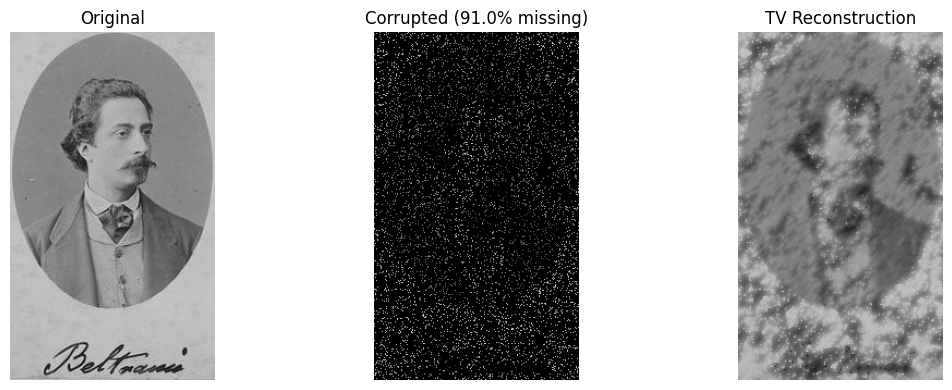

In [4]:

#  1. Load image 
img = Image.open('../Data/Beltrami.jpg').convert('L')  # 'L' converts to grayscale

img = np.array(img, dtype=np.float32) / 255.0         # convert to float in [0,1]
#  2. Mask pixels 
rng = np.random.default_rng(42)

mask_ratio = 0.91   # fraction of pixels removed

mask = rng.uniform(size=img.shape) > mask_ratio
corrupted = img * mask

#  3. TV inpainting 
def grad_tv(u):
    """Compute gradient of isotropic total variation."""
    ux = np.roll(u, -1, axis=1) - u
    uy = np.roll(u, -1, axis=0) - u
    norm = np.sqrt(ux**2 + uy**2 + 1e-8)
    div = (ux / norm) - (np.roll(ux / norm, 1, axis=1))
    div += (uy / norm) - (np.roll(uy / norm, 1, axis=0))
    return -div

def tv_inpaint(corrupted, mask, lam=0.2, n_iter=100, dt=0.1):
    """Basic total variation inpainting via gradient descent."""
    u = corrupted.copy()
    for _ in range(n_iter):
        u -= dt * (lam * grad_tv(u))
        u[mask] = corrupted[mask]   # enforce known pixels
    return np.clip(u, 0, 1)

reconstructed = tv_inpaint(corrupted, mask, lam=0.2, n_iter=100, dt=0.1)

# 4. Visualization 
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
titles = ["Original", f"Corrupted ({mask_ratio*100}% missing)", "TV Reconstruction"]
images = [img, corrupted, reconstructed]

for a, im, t in zip(ax, images, titles):
    a.imshow(im, cmap='gray', vmin=0, vmax=1)
    a.set_title(t)
    a.axis('off')

plt.tight_layout()
plt.show()
